# Multi-Layer Perceptron Neural Network (Pytorch)

## 0. Installation & Imports 

### Torch Installation (MPS)

In [1]:
import torch

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print("MPS device not found.")

tensor([1.], device='mps:0')


### Import Libraries 

In [2]:
# Data Analysis Libraries
import pandas as pd
import numpy as np
from IPython.display import HTML, display
from pprint import pprint

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 7)

# Machine Learning Libraries
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from tqdm import tqdm  # progress bar

# Data Preparation and Evaluation Libraries
import src.data_preprocess as dp
import src.evaluation as ev

print(f"Current pandas version: {pd.__version__}")

Current pandas version: 2.0.3


### Device Agnostic Code

In [3]:
device = "mps" if torch.mps.is_available() else "cpu"
print(f"✅ Using device: {device}")

✅ Using device: mps


## 1. Read Data

In [4]:
df1 = pd.read_csv("data/processed/creditcard_cleaned.csv")
df1.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# some stats about the data
print(f"Number of Data Points: {df1.size}")
print(f"Number of Fradulent Transactions: {df1['Class'].value_counts()[1]}")
print(f"Number of Non-Fradulent Transactions: {df1['Class'].value_counts()[0]}\n")

Number of Data Points: 8795506
Number of Fradulent Transactions: 473
Number of Non-Fradulent Transactions: 283253



## 2. Stratified Splitting 

In [6]:
X = df1.drop(columns=["Class"])
y = df1["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# - Check Class Distribution -
print(y_train.value_counts())
print("==========================")
print(y_test.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


## 3. Feature Scaling 

In [8]:
# - Scaling of Train, Validation, Test Data  -
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()  # set_output(transform="pandas") shouldn't work here (Conversion to Tensor won't work)

# - Train StandardScaler() based on features in Train Data -
X_train_scaled = scaler.fit_transform(X_train)

# - Apply Learning to Test Data -
X_test_scaled = scaler.transform(X_test)

In [9]:
# - Check Scaling Validity Manually -
dp.check_scaling_validity(X_train_scaled)
dp.check_scaling_validity(X_test_scaled)

Feature means after scaling:
 0.04211337257935192

Feature std devs after scaling:
 1.4115090716241605
Feature means after scaling:
 0.04118829144075911

Feature std devs after scaling:
 1.4687385481030577


## 4. Data Preparation 

We will now be converting our training / testing inputs and labels to tensors, which allows Pytorch objects such as `Dataset` and `DataLoader` to interpret them, and distribute them to our neural network in the correct data type.

In [10]:
from torch.utils.data import TensorDataset

X_train_ts = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_ts = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_ts = torch.tensor(y_train.values, dtype=torch.int64)
y_test_ts = torch.tensor(y_test.values, dtype=torch.int64)
train_data = TensorDataset(
    X_train_ts, y_train_ts
)  # auto pairs 1st value of X_train with y_train

# For Features (X): Use FloatTensor (or torch.float32)
# For Classification Labels (y): Use LongTensor (or torch.int64)
# For Regression Targets (y): Use FloatTensor (or torch.float32)

In [11]:
print("Train Data")
print("=" * 25)
print(f"Features dtype: {X_train_ts.dtype}")
print(f"Labels dtype: {y_train_ts.dtype}")

# 5. Check shapes
print(f"X_train Tensor Shape: {X_train_ts.shape}")
print(f"y_train Tensor Shape: {y_train_ts.shape}\n")

print("Test Data")
print("=" * 25)
print(f"Features dtype: {X_test_ts.dtype}")
print(f"Labels dtype: {y_test_ts.dtype}")
print(f"X_test Tensor Shape: {X_test_ts.shape}")
print(f"y_test Tensor Shape: {y_test_ts.shape}")

Train Data
Features dtype: torch.float32
Labels dtype: torch.int64
X_train Tensor Shape: torch.Size([226980, 30])
y_train Tensor Shape: torch.Size([226980])

Test Data
Features dtype: torch.float32
Labels dtype: torch.int64
X_test Tensor Shape: torch.Size([56746, 30])
y_test Tensor Shape: torch.Size([56746])


## 5. Baseline MLP Neural Network Definition
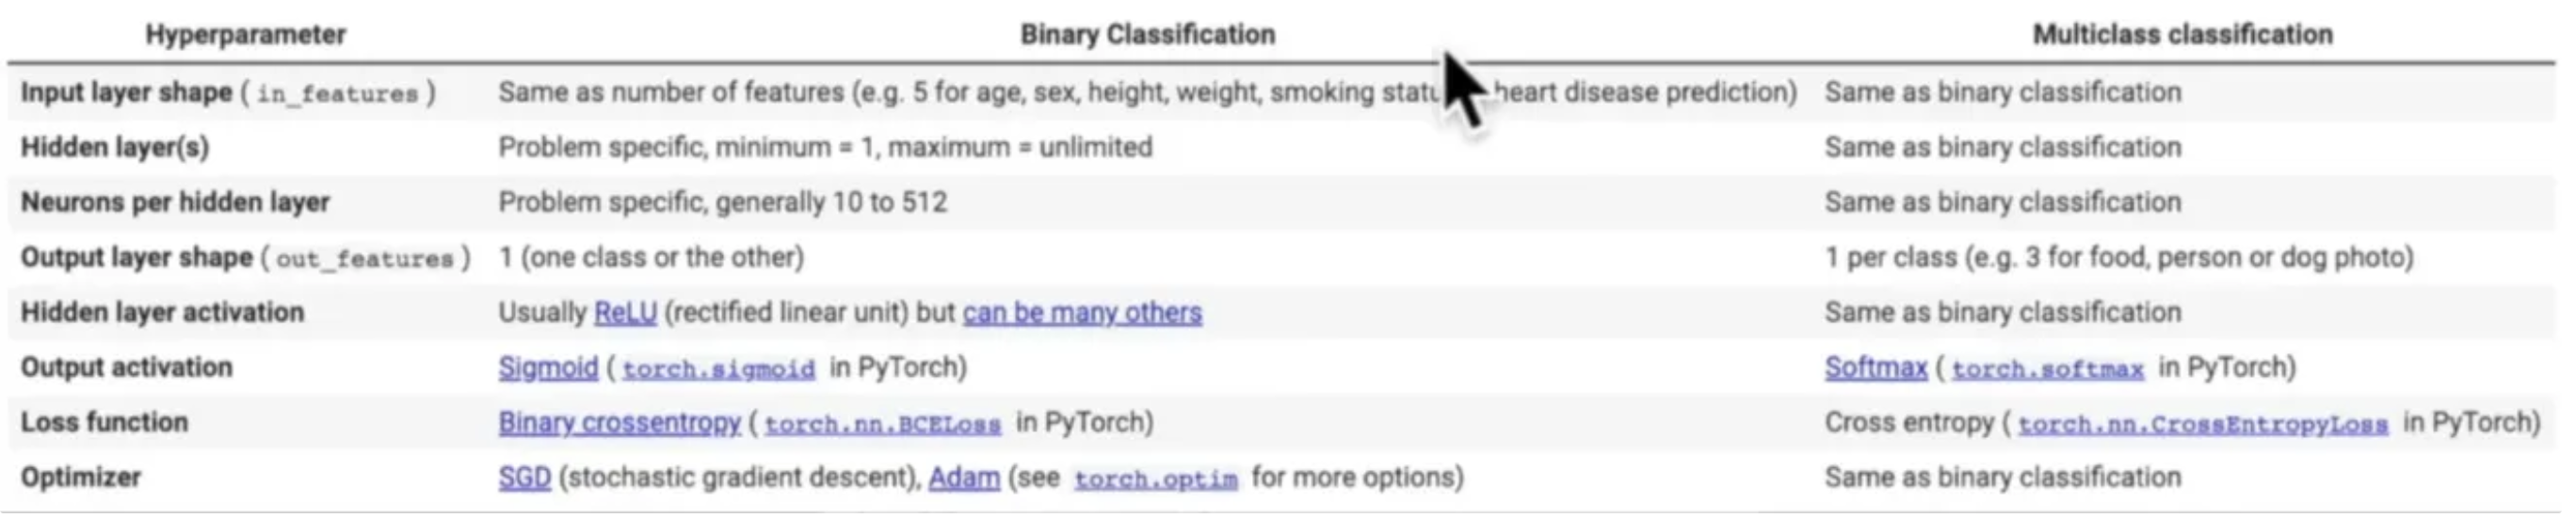

From the Daniel Bourke Pytorch Course, I obtained this guideline for binary vs multiclass classification. This framework shall be referenced to in the following steps. Also, since neural networks learn from complex patterns, there is no need for oversampling / other sampling techniques to address class imbalance. Also, we will be using `BCEWithLogitsLoss` with class weighting for the loss function, since it is numerically more stable and the class weighting approach helps address class imbalance issues. Additionally, our neural network doesn't have a sigmoid application to the output and it outputs raw logits / scores. 

### Compute Class Weights 

In [12]:
# # Dealing with Class Imbalance
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np

# # Calculate class weights
# train_labels = y_train.values

# class_weights = compute_class_weight(
#     "balanced", classes=np.unique(y_train), y=train_labels
# )
# pos_weight_ratio = class_weights[1] / class_weights[0]

# pos_weight_tensor = torch.tensor(pos_weight_ratio, dtype=torch.float32)

# # Before creating the model, add:
# print(f"Class distribution in training: {y_train.value_counts()}")
# print("=" * 30, "\n")
# print(f"Pos weight tensor: {pos_weight_tensor}")
# print(f"This means Fraud class gets {pos_weight_tensor:.2f}x more weight in loss")
# print(
#     "\nInitial: Since Fraud class is minority class, and we are trying to optimize F2 Score, which values Recall more, lets not make class weightage such a high value to avoid overfitting to minority class."
# )
# pos_weight_tensor = pos_weight_tensor / 2
# print(f"Updated Pos weight tensor: {pos_weight_tensor}")
# print(
#     f"Final: This means Fraud class gets {pos_weight_tensor:.2f}x more weight in loss"
# )


### Define Neural Network Architecture (Pytorch Lightning)

In [13]:
import torch
from torch import nn
import lightning as L
import torch.optim as optim
from torchmetrics import MetricCollection
from torchmetrics.classification import (
    BinaryFBetaScore,
    F1Score,
    Precision,
    Recall,
    BinaryAveragePrecision,
)


class FraudNN(L.LightningModule):
    def __init__(
        self,
        input_features,
        hidden_units=128,
        num_layers=3,
        dropout_rate=0.3,
        learning_rate=0.001,
        output_features=1,
        threshold=0.5,
    ):
        super().__init__()

        self.save_hyperparameters()
        self.threshold = threshold
        self.learning_rate = learning_rate

        # ✅ Add average="micro" for epoch-level aggregation (KEY FIX)
        self.train_metrics = MetricCollection(
            {
                "f2": BinaryFBetaScore(beta=2.0, zero_division=0),
                "recall": Recall(task="binary", average="micro", zero_division=0),
                "precision": Precision(task="binary", average="micro"),
                "f1": F1Score(task="binary", average="micro"),
                "ap": BinaryAveragePrecision(thresholds=None),
            },
            prefix="train_",
        )

        self.val_metrics = MetricCollection(
            {
                "f2": BinaryFBetaScore(beta=2.0, zero_division=0),
                "recall": Recall(task="binary", average="micro", zero_division=0),
                "precision": Precision(task="binary", average="micro"),
                "f1": F1Score(task="binary", average="micro"),
                "ap": BinaryAveragePrecision(thresholds=None),
            },
            prefix="val_",
        )

        # Input Layer
        self.input_layer = nn.Sequential(
            nn.Linear(input_features, hidden_units),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )

        # Hidden Layers
        self.hidden_layers = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hidden_units, hidden_units),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                )
                for _ in range(num_layers)
            ]
        )

        # Output Layer
        self.output_layer = nn.Linear(hidden_units, output_features)

        self.criterion = nn.BCEWithLogitsLoss()

    def forward(self, x):
        out = self.input_layer(x)
        for layer in self.hidden_layers:
            out = layer(out)
        out = self.output_layer(out)
        return out

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze()
        probs = torch.sigmoid(logits)
        preds = (probs > self.threshold).int()
        loss = self.criterion(logits, y.float())
        self.train_metrics.update(probs, y.int())

        # if batch_idx % 128 == 0:
        #     # Prediction Distribition
        #     unique_preds, counts = torch.unique(preds, return_counts=True)
        #     print(
        #         f"Training Batch {batch_idx}: Predictions distribution: {dict(zip(unique_preds.cpu().numpy(), counts.cpu().numpy()))}"
        #     )

        #     # Ground Truth Distribution
        #     # Ground truth distribution (ADD THIS)
        #     unique_y, counts_y = torch.unique(y, return_counts=True)
        #     print(
        #         f"Training Batch {batch_idx}: Ground truth distribution: {dict(zip(unique_y.cpu().numpy(), counts_y.cpu().numpy()))}\n"
        #     )

        self.log_dict(self.train_metrics, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze()
        probs = torch.sigmoid(logits)
        preds = (probs > self.threshold).int()
        loss = self.criterion(logits, y.float())
        self.val_metrics.update(probs, y.int())

        # if batch_idx % 128 == 0:
        #     # Predictions distribution
        #     unique_preds, counts = torch.unique(preds, return_counts=True)
        #     print(
        #         f"Validation Batch {batch_idx}: Predictions distribution: {dict(zip(unique_preds.cpu().numpy(), counts.cpu().numpy()))}"
        #     )

        #     # Ground truth distribution (ADD THIS)
        #     unique_y, counts_y = torch.unique(y, return_counts=True)
        #     print(
        #         f"Validation Batch {batch_idx}: Ground truth distribution: {dict(zip(unique_y.cpu().numpy(), counts_y.cpu().numpy()))}\n"
        #     )

        # batch_metrics = self.val_metrics.compute()
        # print(f"Validation Batch {batch_idx}: Batch metrics: {batch_metrics}")

        self.log_dict(self.val_metrics, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.learning_rate)


### Stratified K-Fold Training Loop 

In [14]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset, DataLoader
from torch.utils.data.sampler import WeightedRandomSampler
import torch
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping


kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_metrics = []
seed_everything(42, workers=True)
y_train_np = y_train.values

# SAFETY CHECK: Ensure minority class has enough samples
n_positives = (y_train_np == 1).sum()

if n_positives < 5:
    print(f"Warning: Only {n_positives} positive samples, but n_splits=5")
    print("Reduce n_splits or gather more minority class data")

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_scaled, y_train)):
    print(f"Fold {fold + 1}")

    # FOLD-LEVEL CHECK: Ensure this fold has positive samples
    n_val_positives = (y_train_np[val_idx] == 1).sum()
    if n_val_positives == 0:
        print(f"Skipping fold {fold + 1}: No positive samples in validation set")
        continue

    # Balanced sampling
    w = 1.0 / torch.bincount(torch.tensor(y_train_np[train_idx])).float()
    w = w[torch.tensor(y_train_np[train_idx])]

    train_loader = DataLoader(
        Subset(train_data, train_idx),
        batch_size=128,
        sampler=WeightedRandomSampler(w, len(train_idx), replacement=True),
        num_workers=6,
        persistent_workers=True,
    )

    print(f"Fold {fold + 1} - Train set:")
    print(f"  Total samples: {len(train_idx)}")
    print(f"  Positive samples: {n_positives}")
    print(f"  Positive rate: {n_positives / len(train_idx):.2%}")
    print(f"  Number of batches: {len(train_loader)}")

    val_loader = DataLoader(
        Subset(train_data, val_idx),
        batch_size=128,
        shuffle=False,
        num_workers=6,
        persistent_workers=True,
    )

    # After creating val_loader, add:
    print(f"Fold {fold + 1} - Validation set:")
    print(f"  Total samples: {len(val_idx)}")
    print(f"  Positive samples: {n_val_positives}")
    print(f"  Positive rate: {n_val_positives / len(val_idx):.2%}")
    print(f"  Number of batches: {len(val_loader)}")

    # Check actual validation data distribution
    val_targets = y_train_np[val_idx]
    print(f"  Class distribution: {np.bincount(val_targets)}")

    mlp_model = FraudNN(
        input_features=X_train_ts.shape[1],
        hidden_units=128,
        num_layers=3,
        dropout_rate=0.3,
        learning_rate=0.001,
        output_features=1,
        threshold=0.5,
    )

    wandb_logger = WandbLogger(
        project="Fraud Detection",
        name=f"nn_fold_{fold + 1}",
        group="Pytorch MLP Train-Val CV",
    )

    trainer = Trainer(
        max_epochs=10,
        accelerator="mps",
        devices=1,
        precision="16-mixed",
        logger=wandb_logger,
        callbacks=[
            ModelCheckpoint(monitor="val_f2", mode="max", save_top_k=1),
            EarlyStopping(monitor="val_f2", patience=3, mode="max", verbose=True),
        ],
        deterministic=True,
    )

    trainer.fit(mlp_model, train_loader, val_loader)

    all_metrics.append(trainer.callback_metrics)
    wandb_logger.experiment.finish()


Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/lightning/pytorch/plugins/precision/amp.py:54: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Fold 1
Fold 1 - Train set:
  Total samples: 181584
  Positive samples: 378
  Positive rate: 0.21%
  Number of batches: 1419
Fold 1 - Validation set:
  Total samples: 45396
  Positive samples: 75
  Positive rate: 0.17%
  Number of batches: 355
  Class distribution: [45321    75]


/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or

/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name          | Type              | Params | Mode 
------------------------------------------------------------
0 | train_metrics | MetricCollection  | 0      | train
1 | val_metrics   | MetricCollection  | 0      | train
2 | input_layer   | Sequential        | 4.0 K  | train
3 | hidden_layers | ModuleList        | 49.5 K | train
4 | output_layer  | Linear            | 129    | train
5 | criterion     | BCEWithLogitsLoss | 0      | train
------------------------------------------------------------
53.6 K    Trainable params
0         Non-trainable params
53.6 K    Total params
0.215     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_f2 improved by 0.024 >= min_delta = 0.0. New best score: 0.842


Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▃▃▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇████
train_f1,▁▇████████
train_f2,▁▇████████
train_loss_epoch,█▂▂▁▁▁▁▁▁▁
train_loss_step,▂█▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁
train_precision,▁▇████████
train_recall,▁▇████████
trainer/global_step,▁▁▁▁▁▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
val_ap,▁▄▂▆▂▄██▆█
val_f1,▁▅▆▆▇▆▆▇█▇
+5,...


### Baseline MLP Evaluation

| **Results I** | **Results II** | **Confusion Matrix**
| :---: | :---: | :---:
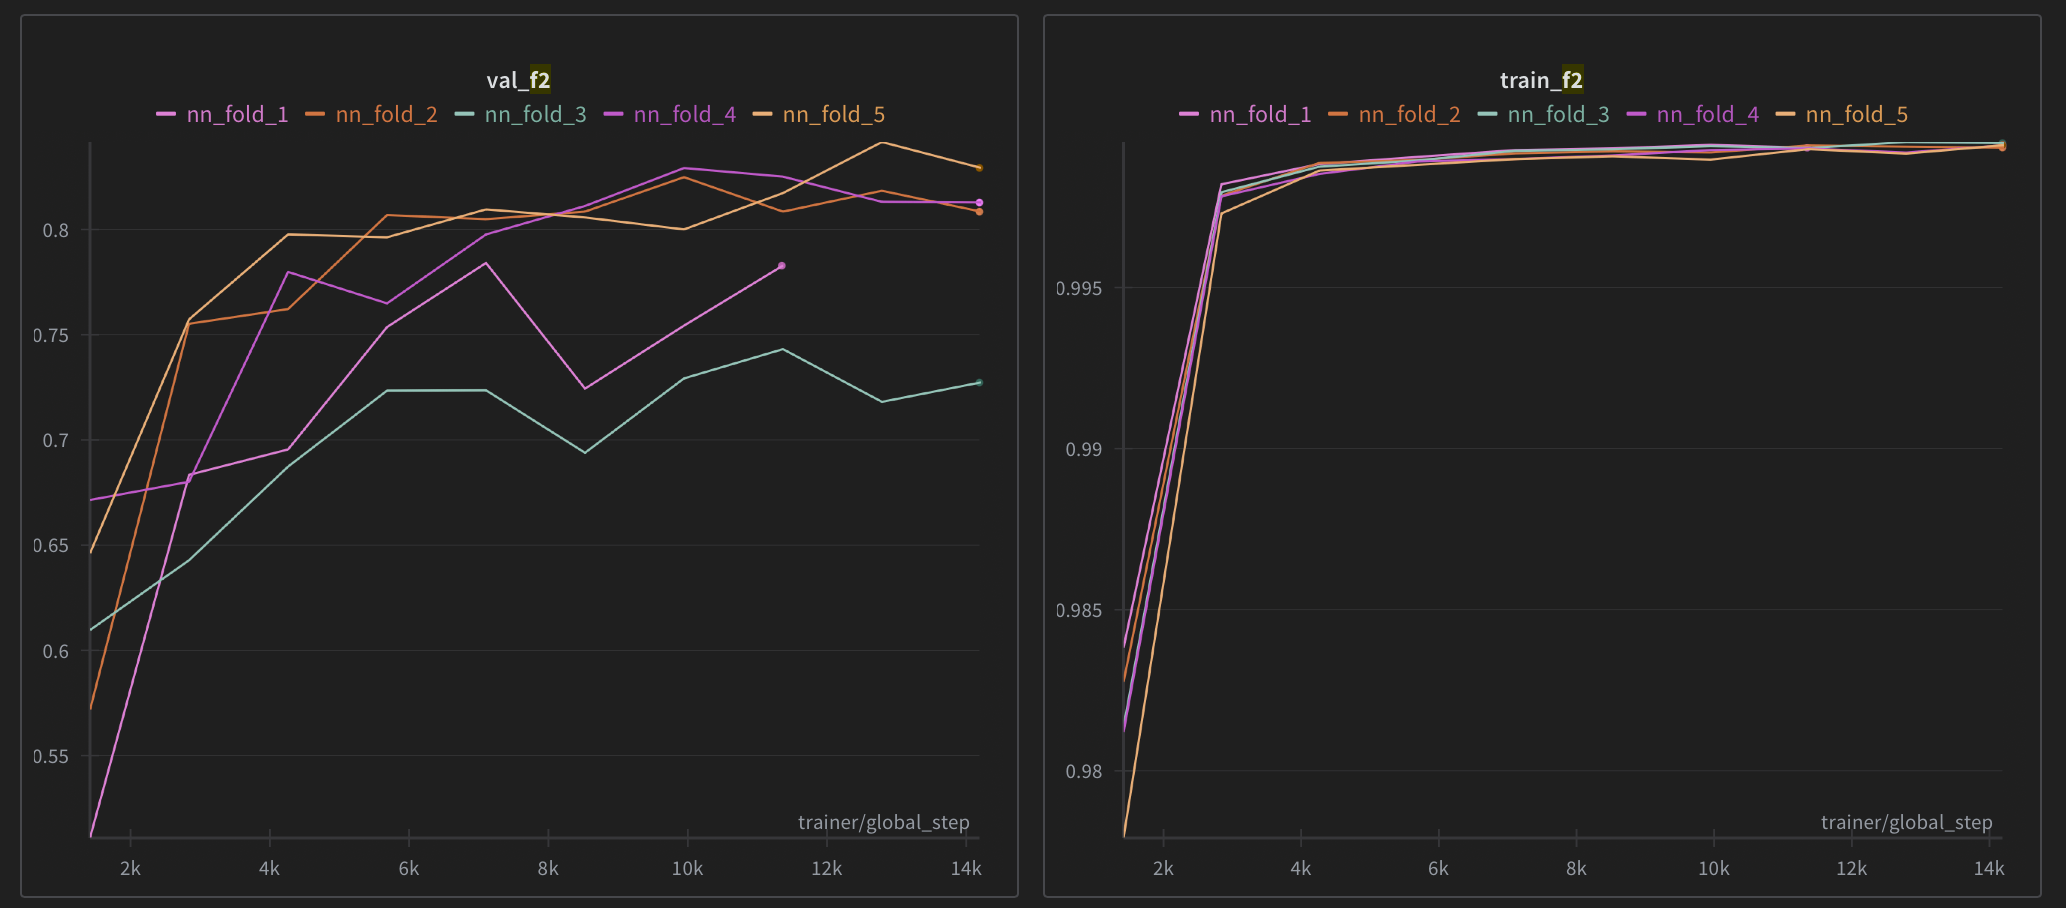 | 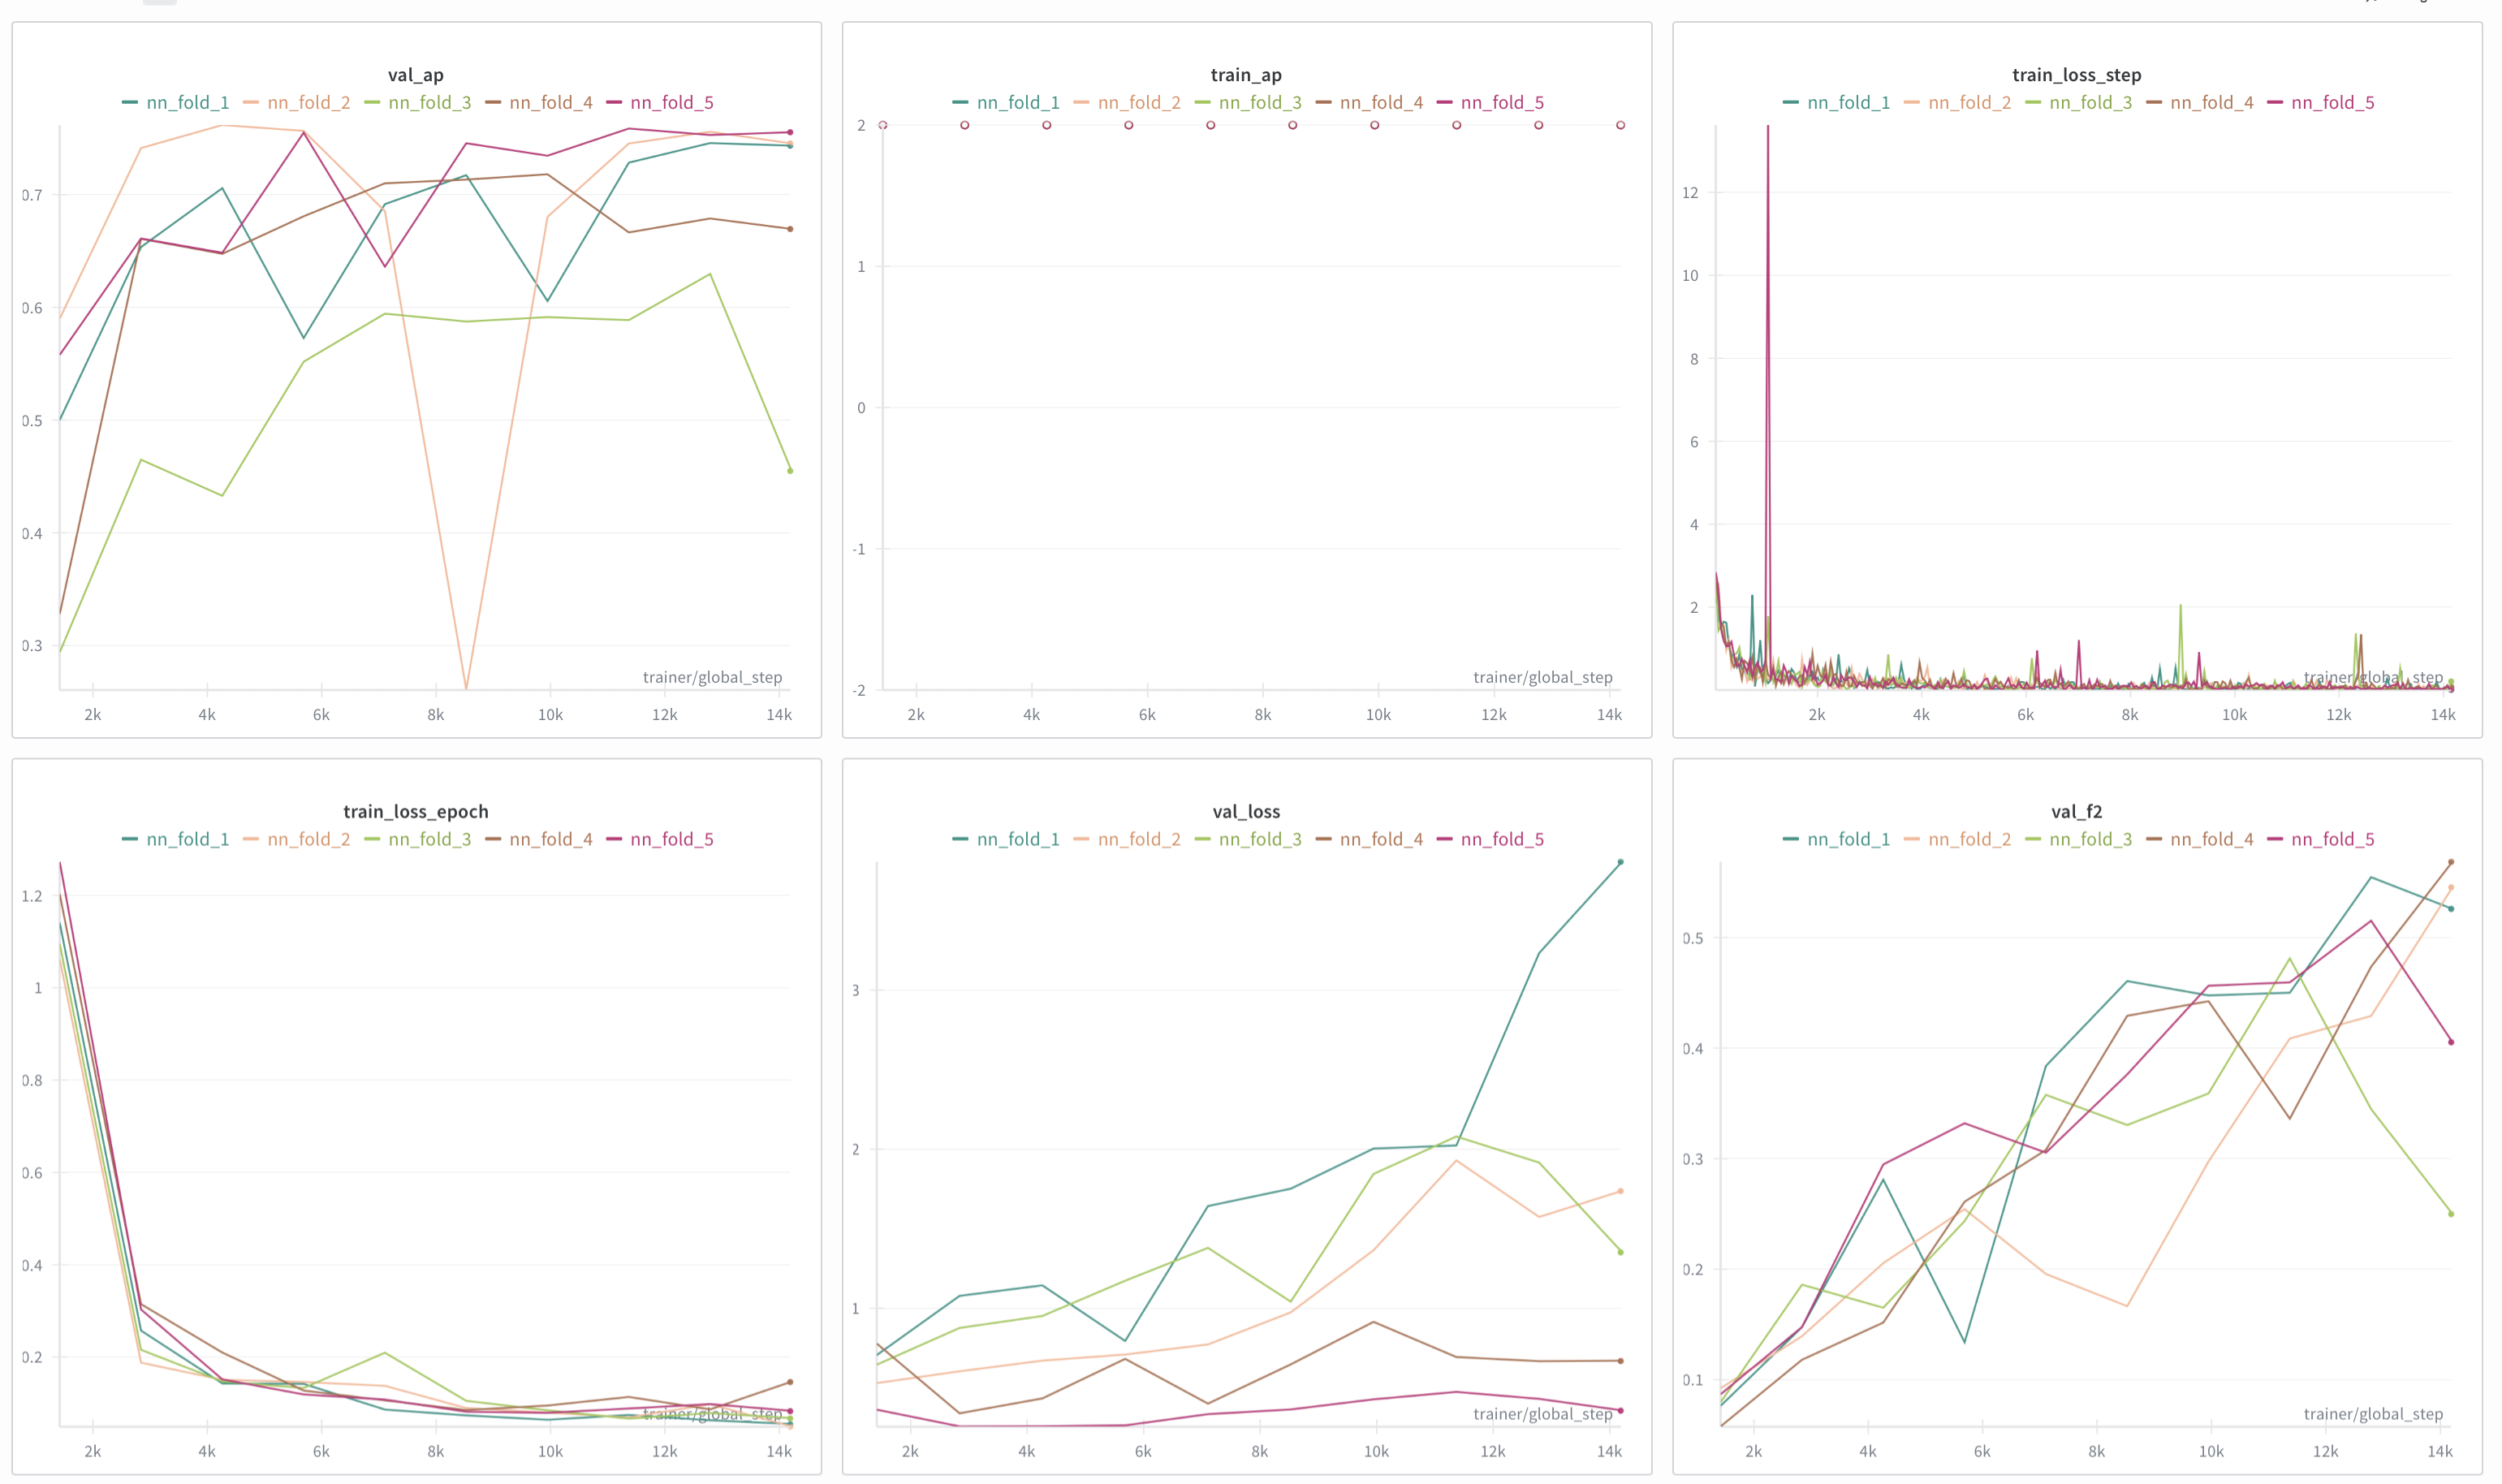 |  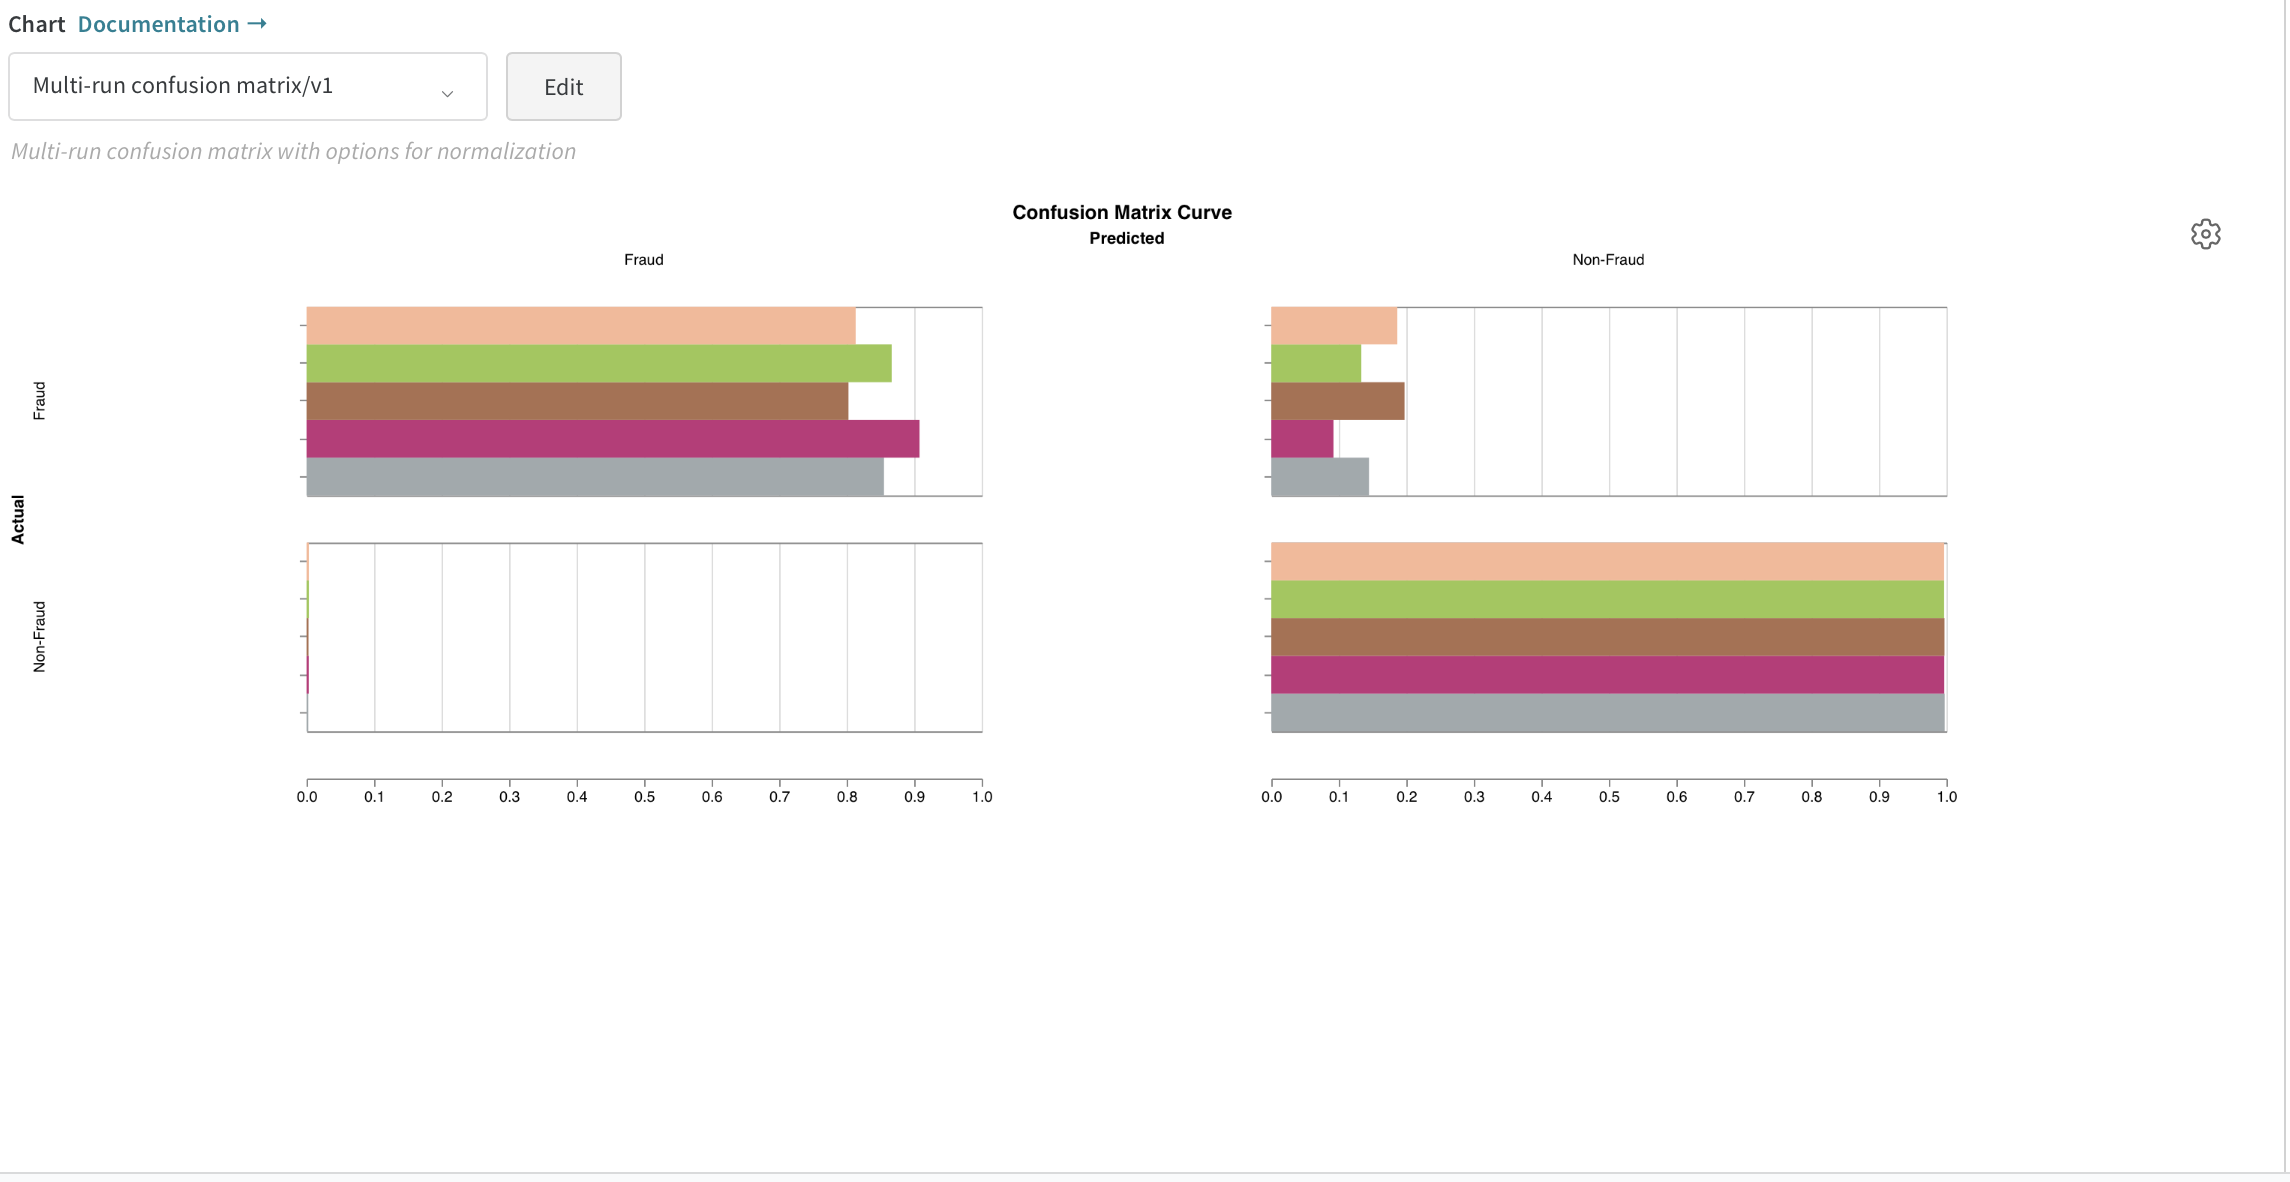 |



In [17]:
scores_across_folds = []
for metric_dict in all_metrics:
    if "val_f2" in metric_dict:
        # Convert tensor to float
        score = metric_dict["val_f2"].cpu().item()
        scores_across_folds.append(score)

print("Scores across folds:", scores_across_folds)
print("Mean F2 score:", sum(scores_across_folds) / len(scores_across_folds))


Scores across folds: [0.7828282713890076, 0.8084577322006226, 0.7272727489471436, 0.8128078579902649, 0.8292682766914368]
Mean F2 score: 0.7921269774436951


## 7. Optuna (Hyperparameter Tuning)

In [15]:
# def objective(trial):
#   """
#   Objective function for optimizing LightGBM AUC
#   """

#   params = {
#         # Learning parameters
#         'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3), # random increments in search space
#         'num_iterations': trial.suggest_int('num_iterations', 100, 1000),

#         # Tree structure parameters
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'num_leaves': trial.suggest_int('num_leaves', 10, 300),
#         'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
#         'max_bin': trial.suggest_int('max_bin', 63, 512),

#         # Regularization parameters
#         'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 10.0),
#         'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 10.0),
#         'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 5.0),
#         'path_smooth': trial.suggest_float('path_smooth', 0.0, 100.0),

#         # Sampling parameters
#         'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
#         'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
#         'bagging_freq': trial.suggest_int('bagging_freq', 0, 7),

#         # Boosting type
#         'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss']),

#         # Fixed parameters
#         'objective': 'binary',
#         'metric': 'binary_logloss',
#         'random_state': 42,
#         'n_jobs': -1,
#         'device_type': 'cpu',
#         'verbose': -1
#      }

#   # Define & Train LightGBM Model
#   model = lgb.LGBMClassifier(**params)
#   model.fit(X_train_resampled, y_train_resampled,
#             eval_set=[(X_val_scaled, y_val)],
#             eval_metric='binary_logloss',
#             early_stopping_rounds=100,
#             verbose=0)

#   # Evaluate on Validation Set (Mu)
#   y_pred = model.predict(X_val_scaled) # class labels
#   y_proba_val = model.predict_proba(X_val_scaled)[:,1] # actual probabilities predicted
#   f1score = f1_score(y_val, y_pred, zero_division=0) # f1 score of positive class
#   recall = recall_score(y_val, y_pred, zero_division=0) # recall of positive class
#   return f1score, recall

# study = optuna.create_study(direction = 'maximize')
# study.optimize(objective,n_trials = 100)